In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
FOLDERS = {
    "research/data/03_hammer_tests/test_01/00_intact": "No fracture hammer 1",
    "research/data/03_hammer_tests/test_01/100_fractured": "100% Fracture hammer 1",
    "research/data/03_hammer_tests/test_02/00_intact": "No fracture hammer 2",
    "research/data/03_hammer_tests/test_02/100_fractured": "100% Fracture hammer 2",
    "research/data/03_hammer_tests/test_03/00_intact": "No fracture hammer 3",
    "research/data/03_hammer_tests/test_03/100_fractured": "100% Fracture hammer 3",
    "research/data/03_hammer_tests/test_04/00_intact": "No fracture hammer 4",
    "research/data/03_hammer_tests/test_04/100_fractured": "100% Fracture hammer 4"
}

group_data = {}

for folder, label in FOLDERS.items():

    csv_files = sorted(Path(folder).glob("*.csv"))

    if not csv_files:
        print(f"No CSV files found in {folder}")
        continue

    impedances = []
    frequency = None

    for csv_file in csv_files:

        df = pd.read_csv(csv_file)

        if frequency is None:
            frequency = df["frequency"].values

        # Skip incomplete sweeps
        if len(df) != len(frequency):
            print(
                f"Skipping {csv_file.name}: "
                f"{len(df)} rows instead of {len(frequency)}"
            )
            continue

        impedances.append(df["impedance"].values)

    if len(impedances) == 0:
        print(f"No valid files found in {folder}")
        continue

    impedances = np.vstack(impedances)

    group_data[label] = {
        "frequency": frequency,
        "mean": np.mean(impedances, axis=0),
        "std": np.std(impedances, axis=0),
        "raw": impedances,
        "n": len(csv_files)
    }

    print(f"{label}: {len(impedances)} files loaded")

No fracture hammer 1: 6 files loaded
100% Fracture hammer 1: 15 files loaded
No fracture hammer 2: 11 files loaded
100% Fracture hammer 2: 14 files loaded
No fracture hammer 3: 7 files loaded
100% Fracture hammer 3: 7 files loaded
No fracture hammer 4: 9 files loaded
100% Fracture hammer 4: 9 files loaded


In [3]:
group_data

{'No fracture hammer 1': {'frequency': array([ 10000.,  11800.,  13600.,  15400.,  17200.,  19000.,  20800.,
          22600.,  24400.,  26200.,  28000.,  29800.,  31600.,  33400.,
          35200.,  37000.,  38800.,  40600.,  42400.,  44200.,  46000.,
          47800.,  49600.,  51400.,  53200.,  55000.,  56800.,  58600.,
          60400.,  62200.,  64000.,  65800.,  67600.,  69400.,  71200.,
          73000.,  74800.,  76600.,  78400.,  80200.,  82000.,  83800.,
          85600.,  87400.,  89200.,  91000.,  92800.,  94600.,  96400.,
          98200., 100000.]),
  'mean': array([532.30333333, 541.14833333, 537.16166667, 531.91833333,
         528.45333333, 534.22166667, 527.78166667, 527.58833333,
         529.46666667, 526.96833333, 520.73      , 521.06333333,
         522.33166667, 521.57      , 519.92      , 518.22833333,
         518.38      , 516.80166667, 521.18      , 515.83      ,
         515.615     , 516.15666667, 512.64166667, 513.33666667,
         519.95      , 511.845  

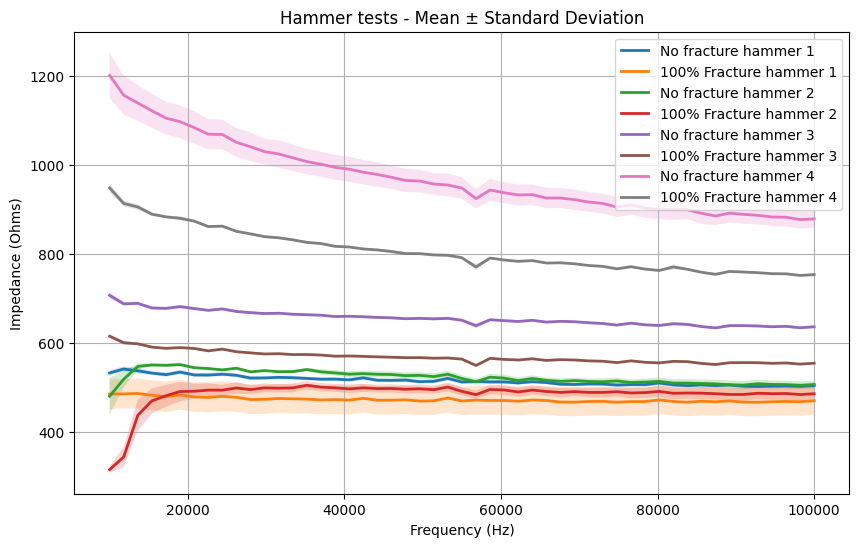

In [4]:
#plot all the relative changes for each hammer
plt.figure(figsize=(10, 6))

for group_name, data in group_data.items():
    plt.plot(
        data["frequency"],
        data["mean"],
        linewidth=2,
        label=group_name
    )

    plt.fill_between(
        data["frequency"],
        data["mean"] - data["std"],
        data["mean"] + data["std"],
        alpha=0.2
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Impedance (Ohms)")
plt.title("Hammer tests - Mean ± Standard Deviation")
plt.legend()
plt.grid()

plt.savefig("hammers_mean_sd.png", dpi=300)
plt.show()

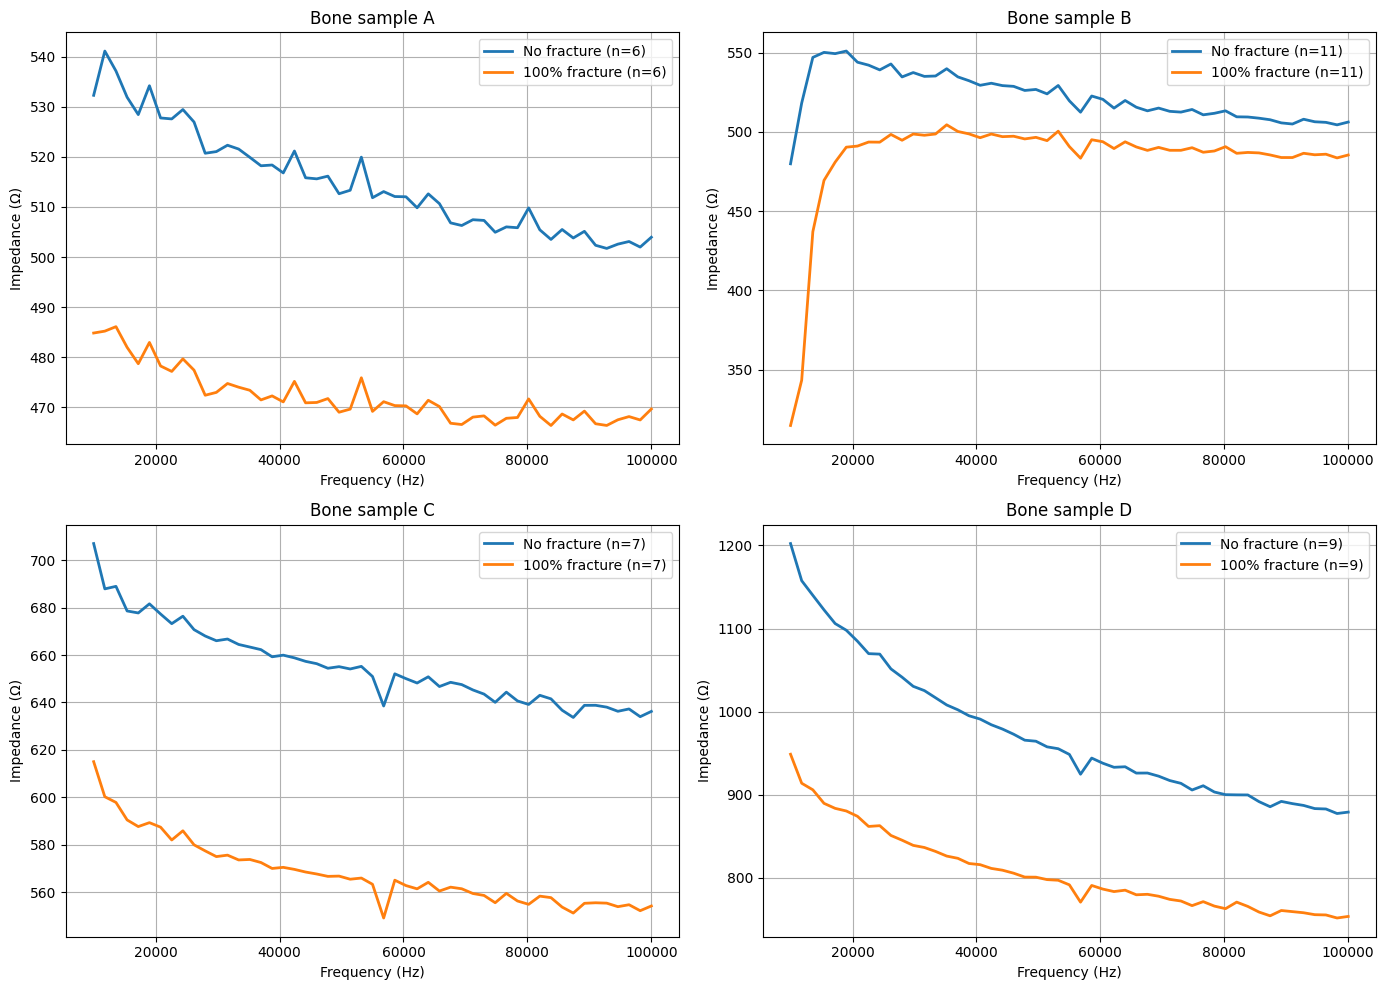

In [5]:
import matplotlib.pyplot as plt

specimen_names = {
    1: "Bone sample A",
    2: "Bone sample B",
    3: "Bone sample C",
    4: "Bone sample D"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, hammer in enumerate([1, 2, 3, 4]):

    intact_key = f"No fracture hammer {hammer}"
    fracture_key = f"100% Fracture hammer {hammer}"

    if intact_key not in group_data or fracture_key not in group_data:
        print(f"Missing data for hammer {hammer}")
        continue

    freq = group_data[intact_key]["frequency"]

    axes[idx].plot(
        freq,
        group_data[intact_key]["mean"],
        label=f"No fracture (n={group_data[intact_key]['n']})",

        linewidth=2
    )

    axes[idx].plot(
        freq,
        group_data[fracture_key]["mean"],
        label=f"100% fracture (n={group_data[intact_key]['n']})",
        linewidth=2
    )

    axes[idx].set_title(specimen_names[hammer])
    axes[idx].set_xlabel("Frequency (Hz)")
    axes[idx].set_ylabel("Impedance (Ω)")
    axes[idx].grid(True)
    axes[idx].legend()

plt.tight_layout()
plt.savefig("hammer_sample_grid_plot.png", dpi=300)
plt.show()

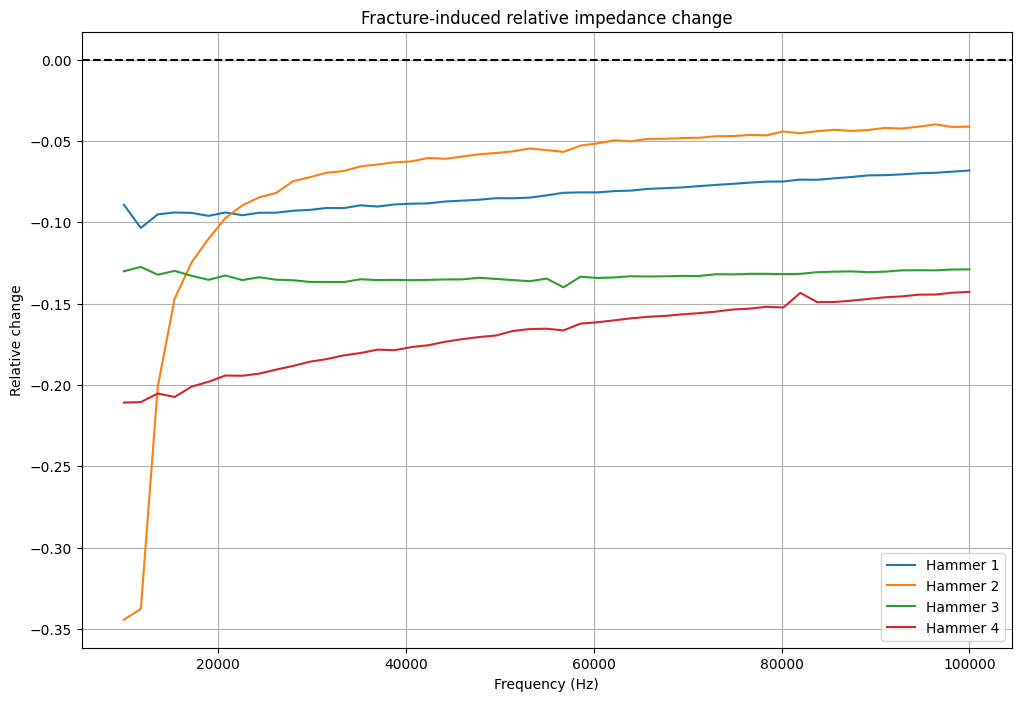

In [6]:
import matplotlib.pyplot as plt
import numpy as np

relative_changes = {}

plt.figure(figsize=(12, 8))

for hammer in [1, 2, 3, 4]:

    intact_key = f"No fracture hammer {hammer}"
    fracture_key = f"100% Fracture hammer {hammer}"

    if intact_key not in group_data or fracture_key not in group_data:
        continue

    freq = group_data[intact_key]["frequency"]

    intact_mean = group_data[intact_key]["mean"]
    fracture_mean = group_data[fracture_key]["mean"]

    # Relative change
    relative_change = (fracture_mean - intact_mean) / intact_mean

    relative_changes[f"hammer_{hammer}"] = relative_change

    plt.plot(
        freq,
        relative_change,
        label=f"Hammer {hammer}"
    )

plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative change")
plt.title("Fracture-induced relative impedance change")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
for hammer, curve in relative_changes.items():
    print(
        hammer,
        f"{curve.mean()*100:.1f}%"
    )

hammer_1 -8.3%
hammer_2 -7.4%
hammer_3 -13.3%
hammer_4 -16.9%


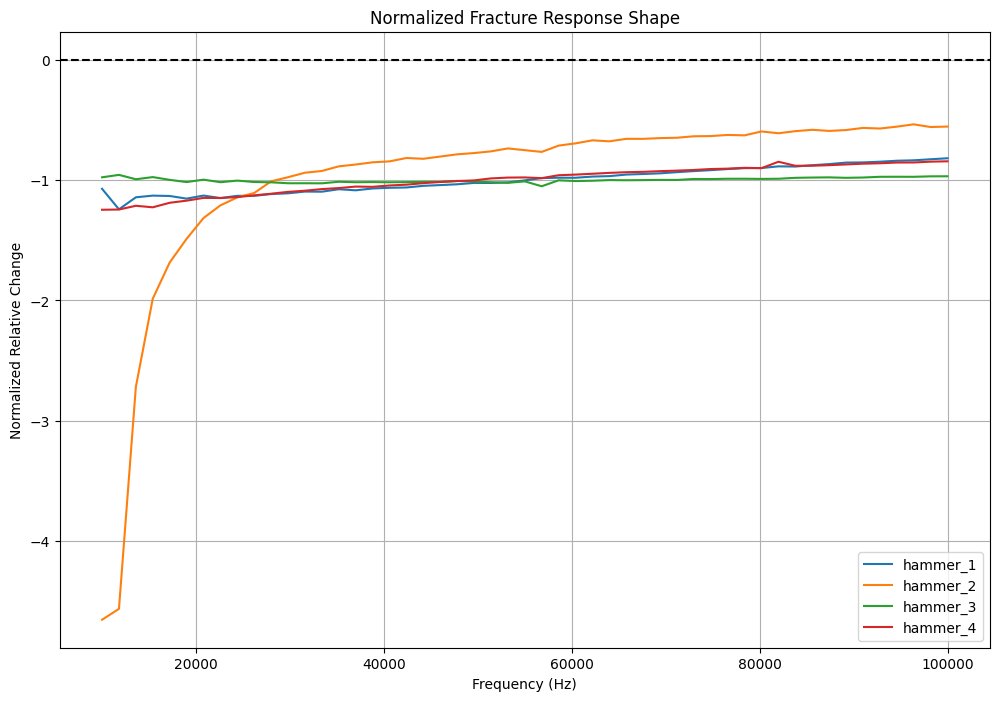

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

normalized_relative_changes = {}

for hammer, curve in relative_changes.items():

    # Normalize by mean magnitude
    normalized_curve = curve / np.abs(curve.mean())

    normalized_relative_changes[hammer] = normalized_curve

    plt.plot(
        freq,
        normalized_curve,
        label=hammer
    )

plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Relative Change")
plt.title("Normalized Fracture Response Shape")
plt.legend()
plt.grid(True)

plt.show()

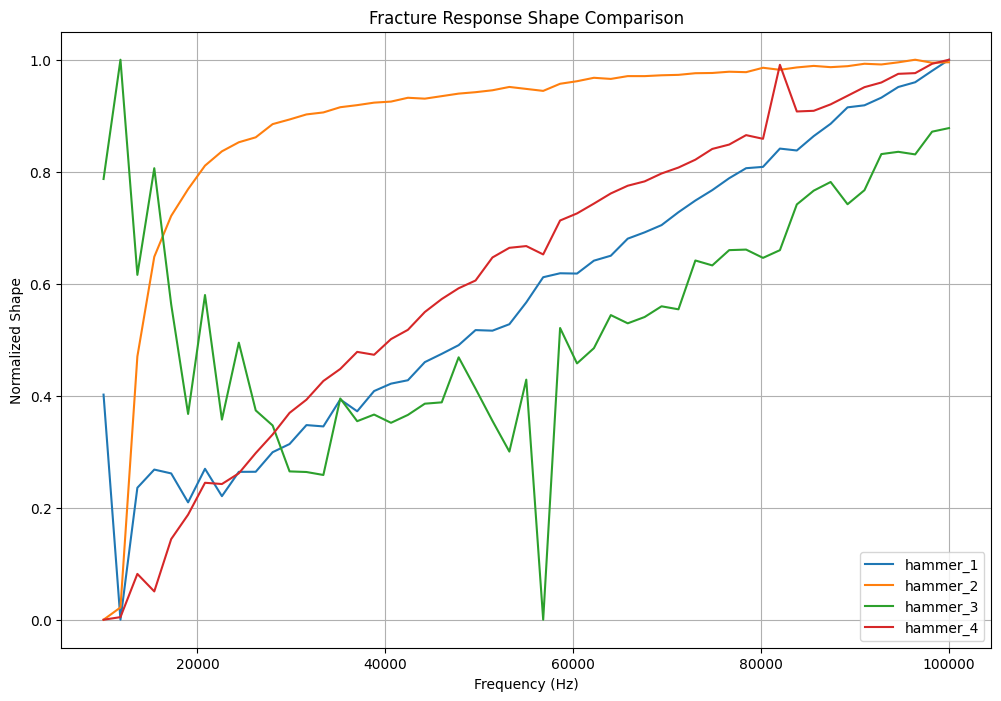

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

shape_curves = {}

for hammer, curve in relative_changes.items():

    curve = np.array(curve)

    # Normalize to [0,1]
    normalized_curve = (
        curve - curve.min()
    ) / (
        curve.max() - curve.min()
    )

    shape_curves[hammer] = normalized_curve

    plt.plot(
        freq,
        normalized_curve,
        label=hammer
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Shape")
plt.title("Fracture Response Shape Comparison")
plt.legend()
plt.grid(True)

plt.show()

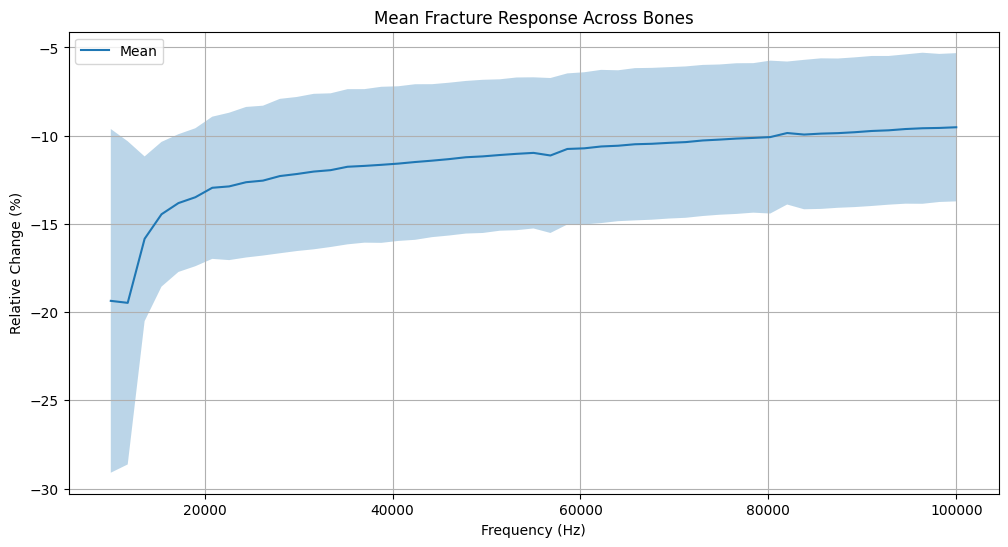

In [10]:
import numpy as np
import matplotlib.pyplot as plt

all_curves = np.array(list(relative_changes.values()))

mean_curve = all_curves.mean(axis=0)
std_curve = all_curves.std(axis=0)

plt.figure(figsize=(12,6))

plt.plot(freq, mean_curve * 100, label="Mean")
plt.fill_between(
    freq,
    (mean_curve - std_curve) * 100,
    (mean_curve + std_curve) * 100,
    alpha=0.3
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative Change (%)")
plt.title("Mean Fracture Response Across Bones")
plt.legend()
plt.grid(True)
plt.show()

Compare every one

In [11]:
import pandas as pd
import numpy as np
from itertools import combinations

rows = []

for hammer in [1, 2, 3, 4]:

    intact_key = f"No fracture hammer {hammer}"
    fracture_key = f"100% Fracture hammer {hammer}"

    intact_sweeps = group_data[intact_key]["raw"]
    fracture_sweeps = group_data[fracture_key]["raw"]

    # Fracture examples
    for intact in intact_sweeps:
        for fractured in fracture_sweeps:

            relative_change = (
                fractured - intact
            ) / intact

            row = dict(zip(freq, relative_change))
            row["broken"] = True
            row["hammer"] = hammer

            rows.append(row)

    # Non-fracture examples
    for intact1, intact2 in combinations(intact_sweeps, 2):

        relative_change = (
            intact2 - intact1
        ) / intact1

        row = dict(zip(freq, relative_change))
        row["broken"] = False
        row["hammer"] = hammer

        rows.append(row)


df_changes = pd.DataFrame(rows)

print(df_changes.shape)
display(df_changes.head())

(501, 53)


,10000.0,11800.0,13600.0,15400.0,17200.0,19000.0,20800.0,22600.0,24400.0,26200.0,...,87400.0,89200.0,91000.0,92800.0,94600.0,96400.0,98200.0,100000.0,broken,hammer
0,-0.167865,-0.171328,-0.166593,-0.167370,-0.166183,-0.169603,-0.164074,-0.167631,-0.162304,-0.163794,...,-0.140804,-0.137477,-0.138711,-0.138827,-0.137818,-0.138193,-0.136126,-0.136395,True,1
1,-0.170384,-0.171181,-0.159095,-0.163356,-0.158369,-0.162127,-0.159384,-0.161693,-0.162154,-0.158686,...,-0.138763,-0.137496,-0.137686,-0.137270,-0.135927,-0.136915,-0.135100,-0.134157,True,1
2,-0.151840,-0.160090,-0.159316,-0.161238,-0.165564,-0.164514,-0.157508,-0.164990,-0.159814,-0.160301,...,-0.140471,-0.139378,-0.137844,-0.138137,-0.137640,-0.137780,-0.135830,-0.136120,True,1
3,-0.147912,-0.171603,-0.163001,-0.167797,-0.160299,-0.163478,-0.160416,-0.164616,-0.158222,-0.160827,...,-0.138802,-0.137555,-0.136622,-0.138176,-0.135848,-0.136207,-0.134588,-0.134294,True,1
4,-0.164456,-0.162826,-0.150879,-0.158433,-0.154191,-0.162442,-0.160172,-0.160850,-0.156649,-0.158499,...,-0.137408,-0.134065,-0.135618,-0.135712,-0.133977,-0.134320,-0.133602,-0.132331,True,1


In [12]:
df_changes

,10000.0,11800.0,13600.0,15400.0,17200.0,19000.0,20800.0,22600.0,24400.0,26200.0,...,87400.0,89200.0,91000.0,92800.0,94600.0,96400.0,98200.0,100000.0,broken,hammer
0,-0.167865,-0.171328,-0.166593,-0.167370,-0.166183,-0.169603,-0.164074,-0.167631,-0.162304,-0.163794,...,-0.140804,-0.137477,-0.138711,-0.138827,-0.137818,-0.138193,-0.136126,-0.136395,True,1
1,-0.170384,-0.171181,-0.159095,-0.163356,-0.158369,-0.162127,-0.159384,-0.161693,-0.162154,-0.158686,...,-0.138763,-0.137496,-0.137686,-0.137270,-0.135927,-0.136915,-0.135100,-0.134157,True,1
2,-0.151840,-0.160090,-0.159316,-0.161238,-0.165564,-0.164514,-0.157508,-0.164990,-0.159814,-0.160301,...,-0.140471,-0.139378,-0.137844,-0.138137,-0.137640,-0.137780,-0.135830,-0.136120,True,1
3,-0.147912,-0.171603,-0.163001,-0.167797,-0.160299,-0.163478,-0.160416,-0.164616,-0.158222,-0.160827,...,-0.138802,-0.137555,-0.136622,-0.138176,-0.135848,-0.136207,-0.134588,-0.134294,True,1
4,-0.164456,-0.162826,-0.150879,-0.158433,-0.154191,-0.162442,-0.160172,-0.160850,-0.156649,-0.158499,...,-0.137408,-0.134065,-0.135618,-0.135712,-0.133977,-0.134320,-0.133602,-0.132331,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,-0.004726,0.017782,0.019598,0.003412,0.002280,-0.001038,0.014468,0.005379,0.004589,-0.001050,...,-0.001860,-0.000304,0.001268,0.000193,-0.001252,-0.000752,-0.002041,0.000756,False,4
497,-0.010599,0.006957,0.007995,0.001045,-0.004450,-0.006490,-0.005817,0.004399,0.001668,-0.002101,...,-0.000590,-0.000575,-0.000396,0.000386,-0.000512,0.000490,0.000757,0.000458,False,4
498,-0.011367,-0.003564,0.011511,0.005765,-0.002278,0.002558,0.007415,0.000187,-0.000384,0.000000,...,-0.001271,0.002112,-0.002144,0.000000,-0.001252,-0.000251,-0.001022,-0.000469,False,4
499,-0.017200,-0.014162,0.000000,0.003393,-0.008978,-0.002914,-0.012729,-0.000787,-0.003291,-0.001051,...,0.000000,0.001841,-0.003803,0.000193,-0.000512,0.000992,0.001779,-0.000766,False,4


In [13]:
X = df_changes.drop(columns=["broken", "hammer"])
y = df_changes["broken"]

In [14]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())

Fold accuracies: [1.   0.92 0.94 0.98 0.96]
Mean accuracy: 0.96
Std: 0.028284271247461894


In [15]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("classifier", LogisticRegression())
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())

Fold accuracies: [1.   0.91 0.92 0.93 0.94]
Mean accuracy: 0.9400000000000001
Std: 0.03162277660168378


In [16]:
print(group_data.keys())

first_key = list(group_data.keys())[0]

print(group_data[first_key].keys())

dict_keys(['No fracture hammer 1', '100% Fracture hammer 1', 'No fracture hammer 2', '100% Fracture hammer 2', 'No fracture hammer 3', '100% Fracture hammer 3', 'No fracture hammer 4', '100% Fracture hammer 4'])
dict_keys(['frequency', 'mean', 'std', 'raw', 'n'])


# test on 1-3, train on 4

In [17]:
train_df = df_changes[df_changes["hammer"].isin([1, 2, 3])]

test_df = df_changes[df_changes["hammer"] == 4]

X_train = train_df.drop(columns=["broken", "hammer"])
y_train = train_df["broken"]

X_test = test_df.drop(columns=["broken", "hammer"])
y_test = test_df["broken"]

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9316239316239316

Confusion Matrix:
[[28  8]
 [ 0 81]]

Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.78      0.88        36
        True       0.91      1.00      0.95        81

    accuracy                           0.93       117
   macro avg       0.96      0.89      0.91       117
weighted avg       0.94      0.93      0.93       117



In [19]:
confusion_matrix(y_test, y_pred)

array([[28,  8],
       [ 0, 81]])